In [1]:
import warnings
warnings.filterwarnings('ignore',category=RuntimeWarning)
import xarray as xr
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import glob,os,sys
from tqdm.auto import tqdm
import proplot as plot
import json,pickle
import dask.array as da
import gc
from tools import derive_var,read_and_proc,preproc_noensemble
from tools.mlr import mlr
from tools.preprocess import do_eof,preproc_maria,preproc_haiyan
from tqdm.auto import tqdm
sys.path.insert(1, '../')
import read_stuff as read
import torch
from torch.utils.data import DataLoader, TensorDataset
import vae3d
from vae3d import VAEEncoder, VAEDecoder, VAE, elbo_loss
import optuna
import torch.nn.functional as F
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import math
import data_process
import random
import preproc_decomp
plot.rc.update({'figure.facecolor':'w','axes.labelweight':'ultralight',
                'tick.labelweight':'ultralight','gridminor.linestyle':'--','title.weight':'normal','linewidth':0.5})
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:32"

/tmp/ipykernel_3314865/2301260017.py:33: ProplotWarning: rc setting 'linewidth' was renamed to 'meta.width' in version 0.8.
  plot.rc.update({'figure.facecolor':'w','axes.labelweight':'ultralight',


In [2]:
device = 'cpu'
folds = data_process.setup_folds(n_numbers=20,indepedent_test={10,17},val_size=4,seed=42)

Fold 1: validation members = [4, 9, 13, 14]
Fold 2: validation members = [5, 6, 7, 18]
Fold 3: validation members = [1, 11, 12, 16]
Fold 4: validation members = [2, 8, 15, 19]
Fold 5: validation members = [0, 3, 13, 14]


# Test

In [3]:
def get_decomp_results(A0,A,B,p,r,a,Q,bc_vert,bc_radial,num_radial,num_vertical,m_azimuthlist=[0,1,2]):
    
    if p[0] > p[-1]:
        p = p[::-1]
        if Q.shape[-1] == len(p):  # Q[r,p]
            Q = Q[:, ::-1]
            
    results = {"r":r, "p":p, "a":a, "Phi":{}, "Wr":{}, "Psi":{}, "Wp":{},
               "coeffs":{"A":{}, "B":{}}, "radial": {},
               "vertical": {},
               "meta":{"bc_radial":bc_radial, "bc_vert":bc_vert},
              "varexplained":{"A":{},"B":{}},
              "hat":{"A":{},"B":{}}
              }

    for m_azimuth in m_azimuthlist:
        Phi, k_mn, Wr = preproc_decomp.radial_modes(r, a, m=m_azimuth, nmax=num_radial, bc=bc_radial)
        Psi, lam, Wp = preproc_decomp.vertical_modes_pressure(p, jmax=num_vertical, bc=bc_vert)
        vert_meta = {"type":"sturm", "lam": lam}
        radial_meta = {"type":"bessel", "k":k_mn}
        
        results['Phi'][m_azimuth] = Phi
        results['Wr'][m_azimuth] = Wr
        results['Psi'][m_azimuth] = Psi
        results['Wp'][m_azimuth] = Wp
        results['radial'][m_azimuth] = radial_meta
        results['vertical'][m_azimuth] = vert_meta
        
        if m_azimuth==0:
            if A0.shape[0] == Psi.shape[0]:  # (Nz, Nr)
                A0 = A0.T
            C = preproc_decomp.project_coefficients(A0, r, p, Phi, Wr, Psi, Wp)
            A0hat = preproc_decomp.reconstruct_field(C, Phi, Psi)
            results["coeffs"]["A"][m_azimuth] = C
            results["varexplained"]["A"][m_azimuth] = 1 - np.sum((A0 - A0hat)**2)/np.sum(A0**2)
            results["hat"]["A"][m_azimuth] = A0hat
            #print(f"Var explained: {1 - np.sum((A0 - A0hat)**2)/np.sum(A0**2):.5f}")
            #print("Coefficients C:\n", np.round(C, 3))
        else:
            A_C = preproc_decomp.project_coefficients(A, r, p, Phi, Wr, Psi, Wp)
            Ahat = preproc_decomp.reconstruct_field(A_C, Phi, Psi)
            results["coeffs"]["A"][m_azimuth] = A_C
            results["varexplained"]["A"][m_azimuth] = 1 - np.sum((A - Ahat)**2)/np.sum(A**2)
            results["hat"]["A"][m_azimuth] = Ahat

            B_C = preproc_decomp.project_coefficients(B, r, p, Phi, Wr, Psi, Wp)
            Bhat = preproc_decomp.reconstruct_field(B_C, Phi, Psi)
            results["coeffs"]["B"][m_azimuth] = B_C
            results["varexplained"]["B"][m_azimuth] = 1 - np.sum((B - Bhat)**2)/np.sum(B**2)
            results["hat"]["B"][m_azimuth] = Bhat
    return results


In [4]:
class decomp_results:
    def __init__(self,trainX,validX,testX,meanstd,p,r,bc_vert,bc_radial,num_radial,num_vertical,azimuthlist):
        self.p=p
        self.r=r
        self.a = self.r.max()
        self.bc_vert = bc_vert
        self.bc_radial = bc_radial
        self.num_vertical = num_vertical
        self.num_radial = num_radial
        self.azimuthlist = azimuthlist
        self.trainX = trainX
        self.validX = validX
        self.testX = testX
        self.meanstd = meanstd
        
    def prep_X(self):
        return {'train':(self.trainX*self.meanstd['stdX']+self.meanstd['meanX']).detach().numpy(),
                'valid':(self.validX*self.meanstd['stdX']+self.meanstd['meanX']).detach().numpy(),
                'test':(self.testX*self.meanstd['stdX']+self.meanstd['meanX']).detach().numpy()
               }
        
    def get_decomp(self,cat=None):
        orig_X = self.prep_X()[cat]
        results = []
        for i in (range(orig_X.shape[0])):
            Q = np.squeeze(orig_X)[i]
            A0, A, B = preproc_decomp.theta_fft_components(Q, axisTHETA=1)
            results.append(get_decomp_results(A0,A,B,self.p,self.r,self.a,Q,self.bc_vert,self.bc_radial,self.num_radial,self.num_vertical,m_azimuthlist=self.azimuthlist))
        return results

    def standardize_training(self,train_coeffs):
        # 1. Calculate the mean (mu) along the time axis (axis=0)
        # The result will have shape (1, R, V) or (R, V) if you don't keep dimensions
        mu = np.mean(train_coeffs, axis=0, keepdims=True)
        # 2. Calculate the standard deviation (sigma) along the time axis (axis=0)
        # We use a small epsilon to prevent division by zero for constant time series.
        epsilon = 1e-16
        sigma = np.std(train_coeffs, axis=0, keepdims=True) + epsilon
        # 3. Apply the standardization formula
        train_coeffs_standardized = (train_coeffs - mu) / sigma
        return train_coeffs_standardized, mu, sigma

    def standardize_valid_test(self,valid_coeffs,test_coeffs,mu,sigma):
        return (valid_coeffs - mu) / sigma, (test_coeffs - mu) / sigma

In [5]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import Lasso

def r2_manual(y_true, y_predicted):
    """
    Calculates the R-squared (R2) score manually without using sklearn.

    Args:
        y_true (np.array or list): The true target values.
        y_predicted (np.array or list): The predicted target values.

    Returns:
        float: The R2 score.
    """
    # Ensure inputs are NumPy arrays for mathematical operations
    y_true = np.array(y_true)
    y_predicted = np.array(y_predicted)

    # 1. Calculate the mean of the true values (y_bar)
    y_mean = np.mean(y_true)

    # 2. Calculate the Total Sum of Squares (SStot)
    # This represents the total variance in y (using y_mean as baseline)
    SStot = np.sum((y_true - y_mean)**2)

    # 3. Calculate the Residual Sum of Squares (SSres)
    # This represents the variance unexplained by the model
    SSres = np.sum((y_true - y_predicted)**2)

    # 4. Calculate R-squared: R2 = 1 - (SSres / SStot)
    if SStot == 0:
        # Avoid division by zero if all y_true values are the same
        return 1.0
    else:
        r2 = 1 - (SSres / SStot)
        return r2
        
def evaluate_lasso_model(model, X, y):
    """
    Evaluates a fitted Lasso regression model on a given dataset (X, y).

    Args:
        model: A fitted sklearn Lasso model.
        X (pd.DataFrame or np.array): Features data.
        y (pd.Series or np.array): True target values.

    Returns:
        dict: A dictionary containing R2, MAE, and MSE scores.
    """
    # 1. Make predictions
    y_pred = model.predict(X)

    # 2. Calculate metrics
    r2 = r2_manual(np.squeeze(y), np.squeeze(y_pred))
    mae = mean_absolute_error(np.squeeze(y), np.squeeze(y_pred))
    mse = mean_squared_error(np.squeeze(y), np.squeeze(y_pred))

    # 3. Return results
    return {
        'R2': r2,
        'MAE': mae,
        'MSE': mse
    }

In [6]:
from collections import defaultdict

train_Xtnsrs = []
val_Xtnsrs = []
test_Xtnsrs = []
train_ytnsrs = []
val_ytnsrs = []
test_ytnsrs = []
meanstds = []
for expnum in range(5):
    _,_,_,_,_,_,train_Xtnsr,train_ytnsr,val_Xtnsr,val_ytnsr,test_Xtnsr,test_ytnsr,input_shape,meanstd = read.tensor_prepare(WSPDpath='./data/storeWSPDn.pkl',\
                                                                                                                            Xpath=f'./data/newadjustedLW/X_cart_newadjustedLW_{expnum}.pkl',\
                                                                                                                            validindex=folds[expnum],\
                                                                                                                            testindex=[17,10],\
                                                                                                                            shuffle=False,\
                                                                                                                            leave100=False)
    train_Xtnsrs.append(train_Xtnsr)
    val_Xtnsrs.append(val_Xtnsr)
    test_Xtnsrs.append(test_Xtnsr)
    train_ytnsrs.append(train_ytnsr)
    val_ytnsrs.append(val_ytnsr)
    test_ytnsrs.append(test_ytnsr)
    meanstds.append(meanstd)

## Get the decomposed coefficients

In [7]:
p = np.linspace(1000,100,10) # hPa
r = np.linspace(0,207,208)*3 # km
a = r.max()
bc_vert = 'neumann'
bc_radial = 'neumann'
num_radial = 5
num_vertical = 2
azimuthlist = [0]

def get_decomp(train_Xs,val_Xs,test_Xs,train_ys,val_ys,test_ys,meanstds,p,r,a,bc_vert,bc_radial,num_rad,num_vert,azimuthlist):
    train_decomps,valid_decomps,test_decomps = [],[],[]
    for expnum in tqdm([0,1,2,3,4]):
        train_Xtnsr,val_Xtnsr,test_Xtnsr = train_Xs[expnum],val_Xs[expnum],test_Xs[expnum]
        train_ytnsr,val_ytnsr,test_ytnsr = train_ys[expnum],val_ys[expnum],test_ys[expnum]
        meanstd = meanstds[expnum]
        train_decomp = decomp_results(train_Xtnsr,val_Xtnsr,test_Xtnsr,meanstd,
                                               p,r,bc_vert,bc_radial,num_rad,num_vert,azimuthlist).get_decomp('train')
        valid_decomp = decomp_results(train_Xtnsr,val_Xtnsr,test_Xtnsr,meanstd,
                                               p,r,bc_vert,bc_radial,num_rad,num_vert,azimuthlist).get_decomp('valid')
        test_decomp = decomp_results(train_Xtnsr,val_Xtnsr,test_Xtnsr,meanstd,
                                               p,r,bc_vert,bc_radial,num_rad,num_vert,azimuthlist).get_decomp('test')
        train_decomps.append(train_decomp)
        valid_decomps.append(valid_decomp)
        test_decomps.append(test_decomp)
    return train_decomps,valid_decomps,test_decomps

In [11]:
train_decomps,valid_decomps,test_decomps = get_decomp(train_Xtnsrs,val_Xtnsrs,test_Xtnsrs,train_ytnsrs,val_ytnsrs,test_ytnsrs,meanstds,
                                                             p,r,a,bc_vert,bc_radial,num_radial,num_vertical,azimuthlist)

  0%|          | 0/5 [00:00<?, ?it/s]

(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)
(208,)

KeyboardInterrupt: 

### Reconstruct original signal

In [19]:
Nth = 360  # or whatever your original azimuthal resolution was
theta = np.linspace(0, 2*np.pi, Nth, endpoint=False)

# Reconstruct Q_m=1(r, θ)
Q_m1 = np.outer((train_decomps[0][0])['hat']['A'][1][2,:,:], np.cos(theta)) + np.outer((train_decomps[0][0])['hat']['B'][1][2,:,:], np.sin(theta))

### Take a look at the structure correponding to the coefficients

In [22]:
# select bases
phi_n = train_decomps[0][0]['Phi'][1][:, 4]     # radial profile (Nr,)
psi_j = train_decomps[0][0]['Psi'][1][:, 1]        # vertical profile (Np,)
theta = np.linspace(0, 2*np.pi, Nth, endpoint=False)

# build 3D structure (r, θ, p)
R, TH, P = np.meshgrid(r, theta, p, indexing='ij')

# outer products
Phi_part = phi_n[:, None, None]         # (Nr, 1, 1)
Psi_part = psi_j[None, None, :]         # (1, 1, Np)
Theta_part = np.cos(0*TH)               # or np.sin(m*TH)

Q_basis = Phi_part * Psi_part * Theta_part

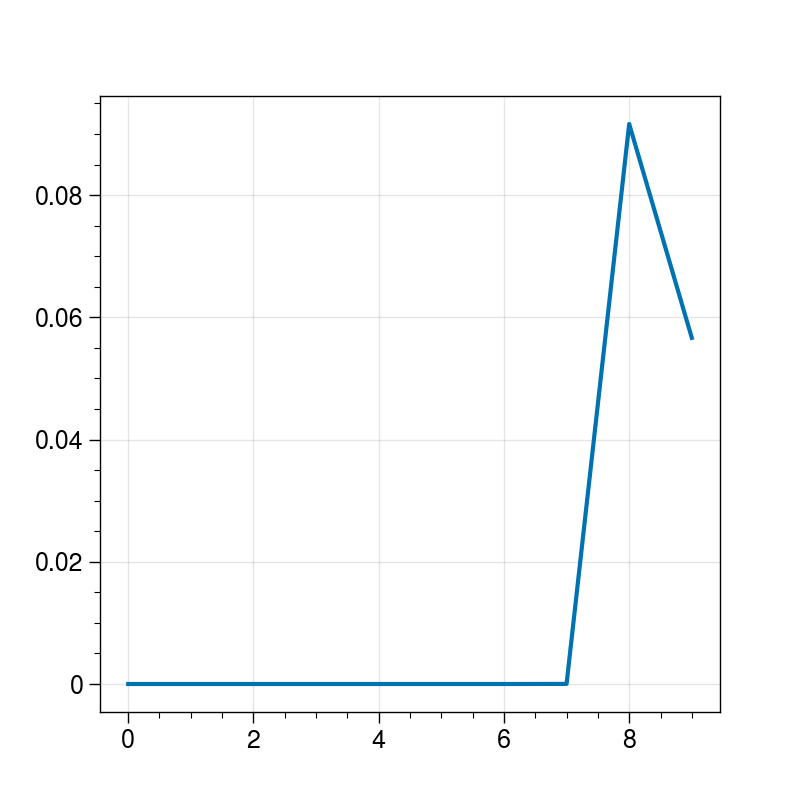

In [23]:
plt.plot(train_decomps[0][0]['Psi'][1][:,0])

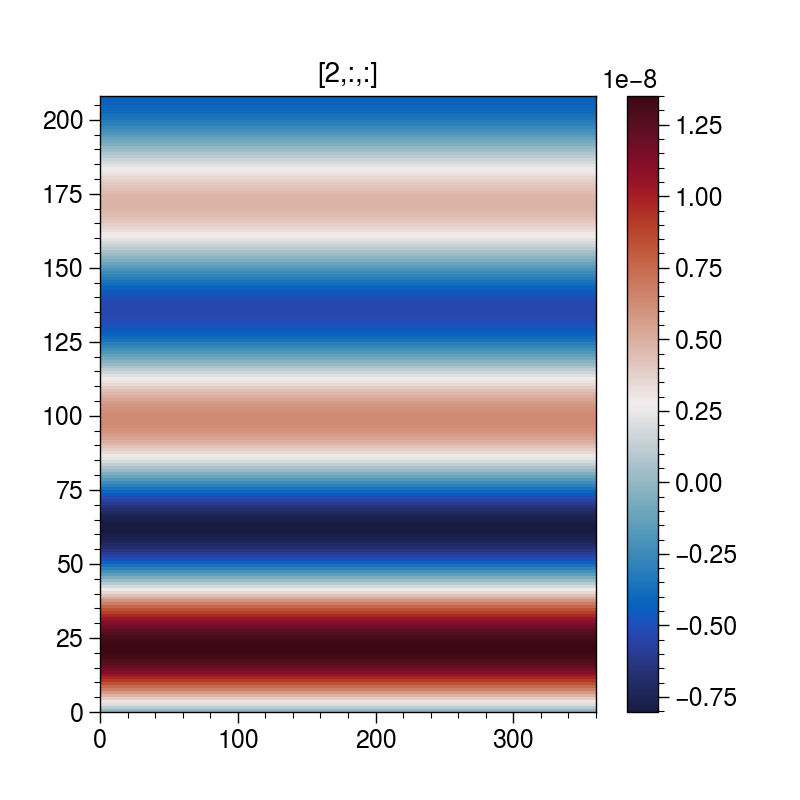

In [24]:
plt.pcolormesh(Q_basis[:,:,0],cmap='balance')
plt.title('[2,:,:]')
plt.colorbar()

## RidgeCV with PLS

In [28]:
p = np.linspace(1000, 100, 10)  # hPa
r = np.linspace(0, 207, 208) * 3  # km
a = r.max()
bc_vert = 'neumann'
bc_radial = 'neumann'
#num_radial = 2
#num_vertical = 9
azimuthlist = [0]
PLS_k = 8
from sklearn.cross_decomposition import PLSRegression
num_rad = 8
num_vert = 12

train_pmce, valid_pmce, test_pmce = [], [], []
models = []

#def train_lasso_with_pls(train_Xs,val_Xs,test_Xs,train_ys,val_ys,test_ys,meanstds,p,r,a,bc_vert,bc_radial,num_rad,num_vert,azimuthlist,lassoalpha):
    
for expnum in tqdm([0, 1, 2, 3, 4]):
    train_Xtnsr, val_Xtnsr, test_Xtnsr = train_Xtnsrs[expnum], val_Xtnsrs[expnum], test_Xtnsrs[expnum]
    train_ytnsr, val_ytnsr, test_ytnsr = train_ytnsrs[expnum], val_ytnsrs[expnum], test_ytnsrs[expnum]
    meanstd = meanstds[expnum]
    train_decomp = decomp_results(train_Xtnsr, val_Xtnsr, test_Xtnsr, meanstd,
                                  p, r, bc_vert, bc_radial, num_rad, num_vert, azimuthlist).get_decomp('train')
    valid_decomp = decomp_results(train_Xtnsr, val_Xtnsr, test_Xtnsr, meanstd,
                                    p, r, bc_vert, bc_radial, num_rad, num_vert, azimuthlist).get_decomp('valid')
    test_decomp = decomp_results(train_Xtnsr, val_Xtnsr, test_Xtnsr, meanstd,
                                 p, r, bc_vert, bc_radial, num_rad, num_vert, azimuthlist).get_decomp('test')
    
    train_coeffs = np.asarray([train_decomp[i]['coeffs']['A'][0] for i in range(len(train_decomp))])
    valid_coeffs = np.asarray([valid_decomp[i]['coeffs']['A'][0] for i in range(len(valid_decomp))])
    test_coeffs = np.asarray([test_decomp[i]['coeffs']['A'][0] for i in range(len(test_decomp))])
    
    train_coeffs_standardized, mu, sigma = decomp_results(train_Xtnsr, val_Xtnsr, test_Xtnsr, meanstd,
                                                              p, r, bc_vert, bc_radial, num_rad, num_vert, azimuthlist).standardize_training(train_coeffs)
    valid_coeffs_standardized, test_coeffs_standardized = decomp_results(train_Xtnsr, val_Xtnsr, test_Xtnsr, meanstd,
                                                              p, r, bc_vert, bc_radial, num_rad, num_vert, azimuthlist).standardize_valid_test(valid_coeffs, test_coeffs, mu, sigma)

    train_coeffs_unstandardized = (train_coeffs_standardized*sigma)+mu
    valid_coeffs_unstandardized = (valid_coeffs_standardized*sigma)+mu
    test_coeffs_unstandardized = (test_coeffs_standardized*sigma)+mu
    train_valid_X = np.concatenate([train_coeffs_standardized,valid_coeffs_standardized],axis=0)
    train_valid_y = np.concatenate([train_ytnsr,val_ytnsr],axis=0)
    # --- 4. Train the Final PLS Model and Transform Data ---
    pls_model = PLSRegression(n_components=PLS_k, scale=False)
    pls_model.fit(train_valid_X.reshape(train_valid_X.shape[0],-1), train_valid_y)

    # Transform the standardized coefficients to the new, low-dimensional PLS space
    X_train_pls = pls_model.transform(train_coeffs_unstandardized.reshape(train_coeffs_unstandardized.shape[0],-1))
    X_valid_pls = pls_model.transform(valid_coeffs_unstandardized.reshape(valid_coeffs_unstandardized.shape[0],-1))
    X_test_pls = pls_model.transform(test_coeffs_unstandardized.reshape(test_coeffs_unstandardized.shape[0],-1))

    mean_pls,std_pls = np.mean(X_train_pls,axis=0,keepdims=True),np.std(X_train_pls,axis=0,keepdims=True)
    X_train_pls_std = (X_train_pls-mean_pls)/std_pls
    X_valid_pls_std = (X_valid_pls-mean_pls)/std_pls
    X_test_pls_std = (X_test_pls-mean_pls)/std_pls
    
    from sklearn import linear_model
    clf = linear_model.RidgeCV(alphas=np.logspace(-3, 3, 20))    #Lasso(alpha=0.1)
    clf.fit(X_train_pls_std, train_ytnsr.detach().numpy())
    models.append(clf)
    
    train_pmce.append(evaluate_lasso_model(clf, X_train_pls_std, train_ytnsr.detach().numpy()))
    valid_pmce.append(evaluate_lasso_model(clf, X_valid_pls_std, val_ytnsr.detach().numpy()))
    test_pmce.append(evaluate_lasso_model(clf, X_test_pls_std, test_ytnsr.detach().numpy()))
    #return train_pmce,valid_pmce,test_pmce,models

  0%|          | 0/5 [00:00<?, ?it/s]

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/work/FAC/FGSE/IDYST/tbeucler/default/freddy0218/miniconda3/envs/fred_workenv/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3552, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_365888/1567718691.py", line 23, in <cell line: 19>
    train_decomp = decomp_results(train_Xtnsr, val_Xtnsr, test_Xtnsr, meanstd,
  File "/tmp/ipykernel_365888/3530975720.py", line 27, in get_decomp
    A0, A, B = preproc_decomp.theta_fft_components(Q, axisTHETA=1)
  File "/work/FAC/FGSE/IDYST/tbeucler/default/freddy0218/2024_TCG_VED_WRFsen/haiyan/preproc_decomp.py", line 10, in theta_fft_components
    F = np.fft.rfft(Q, axis=axisTHETA) # Perform FFT on the azimuthal axis
  File "/work/FAC/FGSE/IDYST/tbeucler/default/freddy0218/miniconda3/envs/fred_workenv/lib/python3.9/site-packages/numpy/fft/_pocketfft.py", line 409, in rfft
    output = _raw_fft(a, n, axis, True, True, inv_norm)
  File "/work/FAC/FGSE/I

TypeError: object of type 'NoneType' has no len()

## Lasso with direct coefficients

In [13]:
def train_lasso(train_Xs,val_Xs,test_Xs,train_ys,val_ys,test_ys,meanstds,p,r,a,bc_vert,bc_radial,num_rad,num_vert,azimuthlist,lassoalpha,num_rad_1,num_vert_1,wv1):
    train_pmce,valid_pmce,test_pmce = [],[],[]
    X,y = [],[]
    models = []
    mus,sigmas = [],[]
    mus_wv1,mus_wv1_b = [],[]
    sigmas_wv1,sigmas_wv1_b = [],[]
    for expnum in tqdm([0,1,2,3,4]):
        train_Xtnsr,val_Xtnsr,test_Xtnsr = train_Xs[expnum],val_Xs[expnum],test_Xs[expnum]
        train_ytnsr,val_ytnsr,test_ytnsr = train_ys[expnum],val_ys[expnum],test_ys[expnum]
        meanstd = meanstds[expnum]
        train_decomp = decomp_results(train_Xtnsr,val_Xtnsr,test_Xtnsr,meanstd,
                                               p,r,bc_vert,bc_radial,num_rad,num_vert,azimuthlist).get_decomp('train')
        valid_decomp = decomp_results(train_Xtnsr,val_Xtnsr,test_Xtnsr,meanstd,
                                               p,r,bc_vert,bc_radial,num_rad,num_vert,azimuthlist).get_decomp('valid')
        test_decomp = decomp_results(train_Xtnsr,val_Xtnsr,test_Xtnsr,meanstd,
                                               p,r,bc_vert,bc_radial,num_rad,num_vert,azimuthlist).get_decomp('test')

        # A0 components
        train_coeffs = np.asarray([train_decomp[i]['coeffs']['A'][0] for i in range(len(train_decomp))])
        valid_coeffs = np.asarray([valid_decomp[i]['coeffs']['A'][0] for i in range(len(valid_decomp))])
        test_coeffs = np.asarray([test_decomp[i]['coeffs']['A'][0] for i in range(len(test_decomp))])
        
        if wv1:
            # A1 components
            train_coeffs_wv1 = np.asarray([train_decomp[i]['coeffs']['A'][1] for i in range(len(train_decomp))])[:,0,:num_rad_1,:num_vert_1]
            valid_coeffs_wv1 = np.asarray([valid_decomp[i]['coeffs']['A'][1] for i in range(len(valid_decomp))])[:,0,:num_rad_1,:num_vert_1]
            test_coeffs_wv1 = np.asarray([test_decomp[i]['coeffs']['A'][1] for i in range(len(test_decomp))])[:,0,:num_rad_1,:num_vert_1]
        
            train_coeffs_wv1_b = np.asarray([train_decomp[i]['coeffs']['B'][1] for i in range(len(train_decomp))])[:,0,:num_rad_1,:num_vert_1]
            valid_coeffs_wv1_b = np.asarray([valid_decomp[i]['coeffs']['B'][1] for i in range(len(valid_decomp))])[:,0,:num_rad_1,:num_vert_1]
            test_coeffs_wv1_b = np.asarray([test_decomp[i]['coeffs']['B'][1] for i in range(len(test_decomp))])[:,0,:num_rad_1,:num_vert_1]  
        
    
        train_coeffs_s_wv0, mu, sigma = decomp_results(train_Xtnsr,val_Xtnsr,test_Xtnsr,meanstd,
                                                                p,r,bc_vert,bc_radial,num_rad,num_vert,azimuthlist).standardize_training(train_coeffs)
        valid_coeffs_s_wv0, test_coeffs_s_wv0 = decomp_results(train_Xtnsr,val_Xtnsr,test_Xtnsr,meanstd,
                                                                p,r,bc_vert,bc_radial,num_rad,num_vert,azimuthlist).standardize_valid_test(valid_coeffs,test_coeffs,mu,sigma)
        mus.append(mu)
        sigmas.append(sigma)
        
        mu_wv1,mu_wv1_b = 0,0
        sigma_wv1,sigma_wv1_b = 0,0
        
        if wv1:
            # A1 components
            train_coeffs_s_wv1, mu_wv1, sigma_wv1 = decomp_results(train_Xtnsr,val_Xtnsr,test_Xtnsr,meanstd,
                                                                    p,r,bc_vert,bc_radial,num_rad,num_vert,azimuthlist).standardize_training(train_coeffs_wv1)
            valid_coeffs_s_wv1, test_coeffs_s_wv1 = decomp_results(train_Xtnsr,val_Xtnsr,test_Xtnsr,meanstd,
                                                                    p,r,bc_vert,bc_radial,num_rad,num_vert,azimuthlist).standardize_valid_test(valid_coeffs_wv1,test_coeffs_wv1,mu_wv1,sigma_wv1)
            train_coeffs_s_wv1_b, mu_wv1_b, sigma_wv1_b = decomp_results(train_Xtnsr,val_Xtnsr,test_Xtnsr,meanstd,
                                                                    p,r,bc_vert,bc_radial,num_rad,num_vert,azimuthlist).standardize_training(train_coeffs_wv1_b)
            valid_coeffs_s_wv1_b, test_coeffs_s_wv1_b = decomp_results(train_Xtnsr,val_Xtnsr,test_Xtnsr,meanstd,
                                                                    p,r,bc_vert,bc_radial,num_rad,num_vert,azimuthlist).standardize_valid_test(valid_coeffs_wv1_b,test_coeffs_wv1_b,mu_wv1_b,sigma_wv1_b)
        
        if wv1:
            train_coeffs_standardized = np.concatenate([train_coeffs_s_wv0.reshape(train_coeffs_s_wv0.shape[0],-1),
                                                        train_coeffs_s_wv1.reshape(train_coeffs_s_wv1.shape[0],-1),
                                                       train_coeffs_s_wv1_b.reshape(train_coeffs_s_wv1_b.shape[0],-1)],axis=1)
            valid_coeffs_standardized = np.concatenate([valid_coeffs_s_wv0.reshape(valid_coeffs_s_wv0.shape[0],-1),
                                                        valid_coeffs_s_wv1.reshape(valid_coeffs_s_wv1.shape[0],-1),
                                                       valid_coeffs_s_wv1_b.reshape(valid_coeffs_s_wv1_b.shape[0],-1)],axis=1)
            test_coeffs_standardized = np.concatenate([test_coeffs_s_wv0.reshape(test_coeffs_s_wv0.shape[0],-1),
                                                        test_coeffs_s_wv1.reshape(test_coeffs_s_wv1.shape[0],-1),
                                                      test_coeffs_s_wv1_b.reshape(test_coeffs_s_wv1_b.shape[0],-1)],axis=1)
        else:
            train_coeffs_standardized = train_coeffs_s_wv0.reshape(train_coeffs_s_wv0.shape[0],-1)
            valid_coeffs_standardized = valid_coeffs_s_wv0.reshape(valid_coeffs_s_wv0.shape[0],-1)
            test_coeffs_standardized = test_coeffs_s_wv0.reshape(test_coeffs_s_wv0.shape[0],-1)

        mus_wv1.append(mu_wv1)
        sigmas_wv1.append(sigma_wv1)
        mus_wv1_b.append(mu_wv1_b)
        sigmas_wv1_b.append(sigma_wv1_b)
            
        from sklearn import linear_model
        clf = linear_model.Lasso(alpha=lassoalpha)
        clf.fit(train_coeffs_standardized, train_ytnsr.detach().numpy())
        models.append(clf)
    
        train_pmce.append(evaluate_lasso_model(clf, train_coeffs_standardized, train_ytnsr.detach().numpy()))
        valid_pmce.append(evaluate_lasso_model(clf, valid_coeffs_standardized, val_ytnsr.detach().numpy()))
        test_pmce.append(evaluate_lasso_model(clf, test_coeffs_standardized, test_ytnsr.detach().numpy()))
        X.append({'train':train_coeffs_standardized,'valid':valid_coeffs_standardized,'test':test_coeffs_standardized})
        y.append({'train':train_ytnsr.detach().numpy(),'valid':val_ytnsr.detach().numpy(),'test':test_ytnsr.detach().numpy()})
    return train_pmce,valid_pmce,test_pmce,models,X,y,\
    {'mu_wv0':mus,'sigma_wv0':sigmas,'mu_wv1_a':mus_wv1,'sigma_wv1_a':sigmas_wv1,'mu_wv1_b':mus_wv1_b,'sigma_wv1_b':sigmas_wv1_b}

In [18]:
lassoalpha=0.1
num_rad_1 = 4
num_vert_1 = 4
for num_rad in [5]:#[2,3,4,5,6,7,8,9,10]:
    train_store = defaultdict(dict)
    valid_store = defaultdict(dict)
    test_store = defaultdict(dict)
    model_store = defaultdict(dict)
    X_store = defaultdict(dict)
    y_store = defaultdict(dict)
    meanstd_coeffs_store = defaultdict(dict)
    
    for num_vert in [2,3,4,5,6,7,8,9,10]:
        train_pmce,valid_pmce,test_pmce,models,X,y,meanstd_coeffs = train_lasso(train_Xtnsrs,val_Xtnsrs,test_Xtnsrs,train_ytnsrs,val_ytnsrs,test_ytnsrs,meanstds,
                                                                                p,r,a,bc_vert,bc_radial,num_rad,num_vert,azimuthlist,lassoalpha,num_rad_1,num_vert_1,False)
        train_store[num_rad][num_vert] = train_pmce
        valid_store[num_rad][num_vert] = valid_pmce
        test_store[num_rad][num_vert] = test_pmce
        model_store[num_rad][num_vert] = models
        X_store[num_rad][num_vert] = X
        y_store[num_rad][num_vert] = y
        meanstd_coeffs_store[num_rad][num_vert] = meanstd_coeffs
    read_and_proc.save_to_pickle(f'./newproc/directC/lasso_alpha{lassoalpha}_nr{num_rad}_performance.pkl',{'train':train_store,'valid':valid_store,'test':test_store,'model':model_store,
                                                                                                                 'X':X_store,'y':y_store,
                                                                                                          'meanstd_coeffs':meanstd_coeffs_store})
    del train_store,valid_store,test_store,model_store,X_store,y_store,meanstd_coeffs_store

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

In [15]:
results = read_and_proc.depickle(f'./newproc/directC/lasso_alpha{lassoalpha}_nr{num_rad}_performance.pkl')

In [17]:
results['meanstd_coeffs']

defaultdict(dict,
            {5: {2: {'mu_wv0': [array([[[-0.02510389,  0.06887594],
                        [-0.0125159 , -0.00895832],
                        [-0.00458512, -0.00193498],
                        [-0.00788067, -0.00331321],
                        [-0.00158337, -0.00122366]]]),
                array([[[-0.02871165,  0.07237949],
                        [-0.01424899, -0.01186808],
                        [-0.0011872 , -0.00230843],
                        [-0.00801504, -0.00315796],
                        [-0.00076806, -0.00099339]]]),
                array([[[-0.02385037,  0.07317748],
                        [-0.0148755 , -0.00969984],
                        [-0.00014924, -0.00342067],
                        [-0.01103426, -0.00226312],
                        [-0.00364676, -0.00133054]]]),
                array([[[-0.02568884,  0.07189541],
                        [-0.01524202, -0.00956433],
                        [-0.00262409, -0.00273138],
                     

In [123]:
np.array([obj['R2'] for obj in results['train'][5][2]]).mean()

0.3554385818811462

## Nonlinear models

In [11]:
import xgboost as xgb
import optuna
from xgboost.callback import EarlyStopping

In [12]:
def train_xgboost(train_Xs, val_Xs, test_Xs,
                  train_ys, val_ys, test_ys,
                  meanstds, p, r, a, bc_vert, bc_radial,
                  num_rad, num_vert, azimuthlist,
                  n_trials=30):
    train_pmce, valid_pmce, test_pmce = [], [], []
    models = []

    decomp_X = []
    for expnum in tqdm([0,1,2,3,4]):
        train_Xtnsr, val_Xtnsr, test_Xtnsr = train_Xs[expnum], val_Xs[expnum], test_Xs[expnum]
        train_ytnsr, val_ytnsr, test_ytnsr = train_ys[expnum], val_ys[expnum], test_ys[expnum]
        meanstd = meanstds[expnum]

        # --- Decomposition & standardization ---
        dr = decomp_results(train_Xtnsr, val_Xtnsr, test_Xtnsr, meanstd,
                            p, r, bc_vert, bc_radial, num_rad, num_vert, azimuthlist)
        train_coeffs = np.asarray([d['coeffs']['A'][0] for d in dr.get_decomp('train')])
        valid_coeffs = np.asarray([d['coeffs']['A'][0] for d in dr.get_decomp('valid')])
        test_coeffs  = np.asarray([d['coeffs']['A'][0] for d in dr.get_decomp('test')])
        train_coeffs_standardized, mu, sigma = dr.standardize_training(train_coeffs)
        valid_coeffs_standardized, test_coeffs_standardized = dr.standardize_valid_test(valid_coeffs, test_coeffs, mu, sigma)

        X_train = train_coeffs_standardized.reshape(train_coeffs_standardized.shape[0], -1)
        X_valid = valid_coeffs_standardized.reshape(valid_coeffs_standardized.shape[0], -1)
        X_test  = test_coeffs_standardized.reshape(test_coeffs_standardized.shape[0], -1)
        decomp_X.append({'train':X_train,'valid':X_valid,'test':X_test,'mu':mu,'sigma':sigma})
        y_train, y_valid, y_test = (train_ytnsr.detach().numpy(),
                                    val_ytnsr.detach().numpy(),
                                    test_ytnsr.detach().numpy())

        # --- Optuna objective ---
        def objective(trial):
            params = {
                    "random_state": 42,
                    "n_jobs": -1,
                    
                    # --- Complexity Parameters (Expanded) ---
                    # Allow deeper trees to capture more complex patterns
                    "max_depth": trial.suggest_int("max_depth", 6,12),
                    # Allow less restrictive splitting (lower values)
                    "min_child_weight": trial.suggest_int("min_child_weight", 1,10),
                    # NEW: Requires a large loss reduction to make a split (smoother trees)
                    "gamma": trial.suggest_float("gamma", 0.0, 1.0),        
                    # --- Sampling Parameters (Wider Range) ---
                    "subsample": trial.suggest_float("subsample", 0.5, 0.8), 
                    "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.8),
        
                    # --- Regularization Parameters (Slightly Relaxed/Expanded) ---
                    # Lower starting point to explore less penalized models
                    "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10, log=True),
                    "reg_alpha": trial.suggest_float("reg_alpha",  0.01, 50, log=True),
        
                    # --- Boosting Parameters (Expanded) ---
                    # Wider range for the learning rate
                    "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
                    # Increased maximum number of estimators to suit potentially lower learning rates
                    "n_estimators": trial.suggest_int("n_estimators", 200,800),
                }
            
            model = xgb.XGBRegressor(objective='reg:squarederror',**params)
            model.fit(X_train, y_train,
                      eval_set=[(X_valid, y_valid)],
                      verbose=False)
            preds = model.predict(X_valid)
            return mean_absolute_error(y_valid, preds)

        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

        best_params = study.best_params
        best_model = xgb.XGBRegressor(**best_params)
        best_model.fit(X_train, y_train)

        # --- Evaluate ---
        def rmse(y_true, y_pred):
            return mean_absolute_error(np.squeeze(y_true), np.squeeze(y_pred))

        train_rmse = rmse(y_train, best_model.predict(X_train))
        valid_rmse = rmse(y_valid, best_model.predict(X_valid))
        test_rmse  = rmse(y_test, best_model.predict(X_test))

        train_pmce.append(train_rmse)
        valid_pmce.append(valid_rmse)
        test_pmce.append(test_rmse)
        models.append(best_model)

    return train_pmce, valid_pmce, test_pmce, models, decomp_X

In [13]:
for num_rad in [2,3,4,5,6,7,8,9,10]:
    train_store = defaultdict(dict)
    valid_store = defaultdict(dict)
    test_store = defaultdict(dict)
    model_store = defaultdict(dict)
    X_store = defaultdict(dict)
    y_store = defaultdict(dict)

    for num_vert in [2,3,4,5,6,7,8,9,10]:
        train_pmce, valid_pmce, test_pmce, models, X = train_xgboost(train_Xtnsrs,val_Xtnsrs,test_Xtnsrs,train_ytnsrs,val_ytnsrs,test_ytnsrs,meanstds, 
                                                                     p, r, a, bc_vert, bc_radial,
                                                                     num_vert, num_rad, azimuthlist,
                                                                     n_trials=15)

        train_store[num_rad][num_vert] = train_pmce
        valid_store[num_rad][num_vert] = valid_pmce
        test_store[num_rad][num_vert] = test_pmce
        model_store[num_rad][num_vert] = models
        X_store[num_rad][num_vert] = X
        
    read_and_proc.save_to_pickle(f'./newproc/directC_rf/rf_nr{num_rad}_performance.pkl',{'train':train_store,'valid':valid_store,'test':test_store,'model':model_store,
                                                                                                                 'X':X_store})
    del train_store,valid_store,test_store,model_store

  0%|          | 0/5 [00:00<?, ?it/s]

[I 2025-11-07 14:53:25,141] A new study created in memory with name: no-name-fb33a7fd-897d-4fa1-bcb3-779976eb5559
[I 2025-11-07 14:53:25,316] Trial 0 finished with value: 0.8175016641616821 and parameters: {'max_depth': 10, 'min_child_weight': 4, 'gamma': 0.21770101717727353, 'subsample': 0.7399309117103902, 'colsample_bytree': 0.5884335759562742, 'reg_lambda': 5.810671956580852, 'reg_alpha': 0.2074985340812385, 'learning_rate': 0.09546772988103994, 'n_estimators': 223}. Best is trial 0 with value: 0.8175016641616821.
[I 2025-11-07 14:53:25,403] Trial 1 finished with value: 0.8320034146308899 and parameters: {'max_depth': 11, 'min_child_weight': 1, 'gamma': 0.3710035081070918, 'subsample': 0.5881746522466317, 'colsample_bytree': 0.612386733528521, 'reg_lambda': 0.1767805389145556, 'reg_alpha': 6.553993679927069, 'learning_rate': 0.062241589359166655, 'n_estimators': 693}. Best is trial 0 with value: 0.8175016641616821.
[I 2025-11-07 14:53:25,477] Trial 2 finished with value: 0.84447610

  0%|          | 0/5 [00:00<?, ?it/s]

[I 2025-11-07 14:54:18,801] A new study created in memory with name: no-name-dd5543c4-394f-4bef-92dc-cc7d9083ecfc
[I 2025-11-07 14:54:18,890] Trial 0 finished with value: 0.8027841448783875 and parameters: {'max_depth': 6, 'min_child_weight': 1, 'gamma': 0.73434012531064, 'subsample': 0.5634951663748607, 'colsample_bytree': 0.797476559214567, 'reg_lambda': 0.1691437328724396, 'reg_alpha': 0.012757856041889643, 'learning_rate': 0.10130940635252833, 'n_estimators': 726}. Best is trial 0 with value: 0.8027841448783875.
[I 2025-11-07 14:54:19,000] Trial 1 finished with value: 0.7509272694587708 and parameters: {'max_depth': 10, 'min_child_weight': 9, 'gamma': 0.06332707084388789, 'subsample': 0.653158001528106, 'colsample_bytree': 0.7537556068950619, 'reg_lambda': 0.31601089305532115, 'reg_alpha': 3.3596697323722404, 'learning_rate': 0.03152382775235993, 'n_estimators': 420}. Best is trial 1 with value: 0.7509272694587708.
[I 2025-11-07 14:54:19,100] Trial 2 finished with value: 0.74709630

  0%|          | 0/5 [00:00<?, ?it/s]

...

[I 2025-11-07 16:03:53,146] A new study created in memory with name: no-name-10eb3ca1-e900-4e80-875f-5ab9179bfe16
[I 2025-11-07 16:03:53,475] Trial 0 finished with value: 0.7652957439422607 and parameters: {'max_depth': 12, 'min_child_weight': 3, 'gamma': 0.8821471942942555, 'subsample': 0.5449154978771139, 'colsample_bytree': 0.6220978104336434, 'reg_lambda': 0.21600566412765237, 'reg_alpha': 0.28950506444484864, 'learning_rate': 0.024918451319971915, 'n_estimators': 526}. Best is trial 0 with value: 0.7652957439422607.
[I 2025-11-07 16:03:53,714] Trial 1 finished with value: 0.787611722946167 and parameters: {'max_depth': 7, 'min_child_weight': 8, 'gamma': 0.9417347383432635, 'subsample': 0.6932433075860271, 'colsample_bytree': 0.7285115830627238, 'reg_lambda': 0.25033522844961215, 'reg_alpha': 1.9728360416859043, 'learning_rate': 0.030069841893349672, 'n_estimators': 338}. Best is trial 0 with value: 0.7652957439422607.
[I 2025-11-07 16:03:53,846] Trial 2 finished with value: 0.7761

  0%|          | 0/5 [00:00<?, ?it/s]

[I 2025-11-07 16:04:54,976] A new study created in memory with name: no-name-ed57e1ac-3822-41a5-a364-3decff9ca099
[I 2025-11-07 16:04:55,981] Trial 0 finished with value: 0.8005269765853882 and parameters: {'max_depth': 12, 'min_child_weight': 4, 'gamma': 0.5462354101595034, 'subsample': 0.7944864068040745, 'colsample_bytree': 0.542279713640431, 'reg_lambda': 0.36403870738364447, 'reg_alpha': 0.10314543216548867, 'learning_rate': 0.030617116867207535, 'n_estimators': 740}. Best is trial 0 with value: 0.8005269765853882.
[I 2025-11-07 16:04:56,288] Trial 1 finished with value: 0.8556786179542542 and parameters: {'max_depth': 7, 'min_child_weight': 2, 'gamma': 0.19726815151153443, 'subsample': 0.5932754222152521, 'colsample_bytree': 0.7287917410429425, 'reg_lambda': 0.44738969519186017, 'reg_alpha': 1.970516017860546, 'learning_rate': 0.11016584959022624, 'n_estimators': 729}. Best is trial 0 with value: 0.8005269765853882.
[I 2025-11-07 16:04:56,388] Trial 2 finished with value: 0.81202

  0%|          | 0/5 [00:00<?, ?it/s]

[I 2025-11-07 16:05:58,213] A new study created in memory with name: no-name-dde264a3-e74b-47b1-868f-f05ef381675d
[I 2025-11-07 16:05:58,521] Trial 0 finished with value: 0.795988142490387 and parameters: {'max_depth': 7, 'min_child_weight': 2, 'gamma': 0.07433004847613234, 'subsample': 0.6515971928362398, 'colsample_bytree': 0.6331142466942686, 'reg_lambda': 1.1263306340236963, 'reg_alpha': 0.7275246379760626, 'learning_rate': 0.08363944055762981, 'n_estimators': 488}. Best is trial 0 with value: 0.795988142490387.
[I 2025-11-07 16:05:58,679] Trial 1 finished with value: 0.8014935255050659 and parameters: {'max_depth': 7, 'min_child_weight': 3, 'gamma': 0.650072629402648, 'subsample': 0.7582876577250086, 'colsample_bytree': 0.6087655722853209, 'reg_lambda': 7.217553418163892, 'reg_alpha': 0.32027236151902055, 'learning_rate': 0.07482667796537183, 'n_estimators': 271}. Best is trial 0 with value: 0.795988142490387.
[I 2025-11-07 16:05:58,937] Trial 2 finished with value: 0.820108950138

In [199]:
np.mean(np.asarray(xgb_ts[2]))

0.5256393134593964

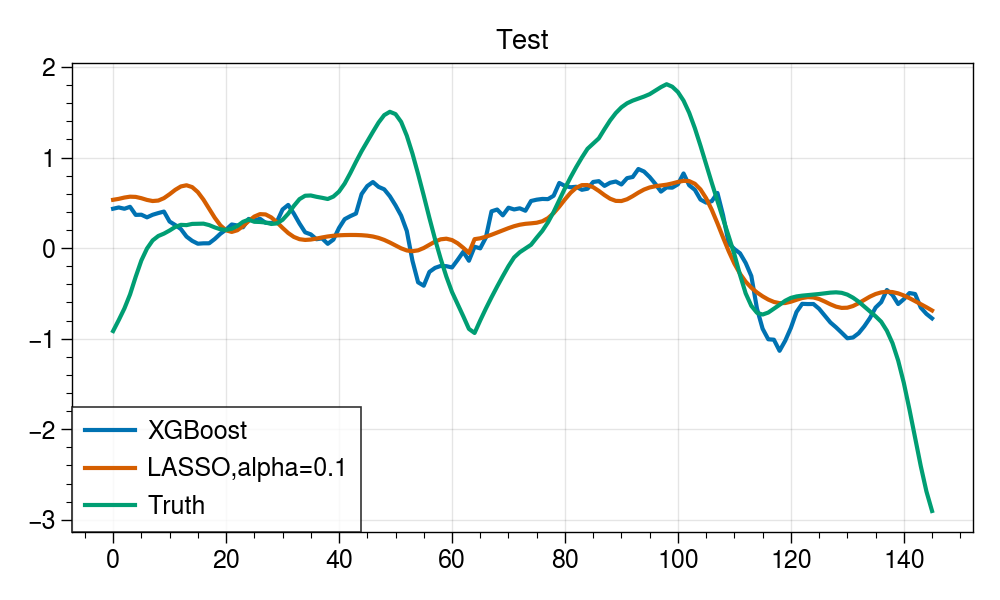

In [200]:
fig, ax = plt.subplots(figsize=(5,3))
plt.plot(np.mean(np.asarray([xgb_ts[-2][i].predict(xgb_ts[-1][0]['test']) for i in range(5)]),axis=0),label='XGBoost')
plt.plot(np.mean(np.asarray([results['model'][5][2][4].predict(xgb_ts[-1][0]['test']) for i in range(5)]),axis=0),label='LASSO,alpha=0.1')
plt.plot(test_ytnsrs[0].detach().numpy().squeeze(),label='Truth')
plt.legend()
plt.title('Test')
plt.
plt.tight_layout()
plt.show()